# Model Experiments - Experimentação de Modelos

Este notebook realiza uma **experimentação comparativa de 5 modelos diferentes** para prever se um aluno está defasado.

## Fluxo
1. Carrega features e dataset processados
2. Faz split treino/validação (80/20)
3. Treina 5 modelos: Regressão Logística, Random Forest, Gradient Boosting, XGBoost e LightGBM
4. Compara métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC
5. Seleciona melhor modelo (maior ROC-AUC)
6. Analisa importância das features

In [18]:
import sys
from pathlib import Path
ROOT_PATH = Path().resolve().parent
sys.path.append(str(ROOT_PATH))
import os
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from src.pipeline import build_pipeline
from src.utils import load_features, load_config
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)
import matplotlib.pyplot as plt

In [2]:
cfg = load_config("../config.yaml")

RANDOM_SEED = cfg["random_seed"]
TARGET = cfg["target"]

FEATURES_JSON = "../artifacts/feature_cols.json"

features = load_features(FEATURES_JSON)

print(f"{len(features)} features carregadas")

7 features carregadas


In [3]:
DATASET_PATH = "../data/processed/dataset_academic.csv"

df = pd.read_csv(DATASET_PATH)

print(df.shape)
df.head()

(3030, 8)


,Matematica,Portugues,Ingles,IDA,Cg,Cf,Ct,defasado_bin
0,2.7,3.5,6.0,4.0,753.0,18.0,10.0,1
1,6.3,4.5,9.7,6.8,469.0,8.0,3.0,0
2,5.8,4.0,6.9,5.6,629.0,13.0,6.0,0
3,2.8,3.5,8.7,5.0,731.0,15.0,7.0,0
4,7.0,2.9,5.7,5.2,344.0,6.0,2.0,0


In [4]:
df = df[features + [TARGET]].copy()

df = df.dropna(subset=[TARGET])

print(df.shape)

(3030, 8)


In [5]:
X = df[features]
y = df[TARGET]

print(X.shape)
print(y.shape)

(3030, 7)
(3030,)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (2424, 7)
Val: (606, 7)


In [7]:
models = [
    "logreg",
    "rf",
    "gb",
    "xgb",
    "lgbm"
]

results = []

for model_name in models:

    print(f"\nTreinando modelo: {model_name}")

    pipeline = build_pipeline(
        features=features,
        model_name=model_name
    )

    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_val)

    # Probabilidades (necessárias para ROC-AUC)
    if hasattr(pipeline, "predict_proba"):
        probs = pipeline.predict_proba(X_val)[:, 1]
    else:
        probs = None

    accuracy = accuracy_score(y_val, preds)
    precision = precision_score(y_val, preds)
    recall = recall_score(y_val, preds)
    f1 = f1_score(y_val, preds)

    roc_auc = roc_auc_score(y_val, probs) if probs is not None else None

    results.append({
        "modelo": model_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc
    })

    print(classification_report(y_val, preds))


Treinando modelo: logreg
              precision    recall  f1-score   support

           0       0.50      0.14      0.22       269
           1       0.56      0.88      0.69       337

    accuracy                           0.56       606
   macro avg       0.53      0.51      0.46       606
weighted avg       0.54      0.56      0.48       606


Treinando modelo: rf
              precision    recall  f1-score   support

           0       0.62      0.62      0.62       269
           1       0.70      0.70      0.70       337

    accuracy                           0.67       606
   macro avg       0.66      0.66      0.66       606
weighted avg       0.67      0.67      0.67       606


Treinando modelo: gb
              precision    recall  f1-score   support

           0       0.70      0.56      0.62       269
           1       0.70      0.80      0.75       337

    accuracy                           0.70       606
   macro avg       0.70      0.68      0.68       606
weig

/home/denilson/git/datathon/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [12:14:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.64      0.61      0.62       269
           1       0.70      0.73      0.71       337

    accuracy                           0.67       606
   macro avg       0.67      0.67      0.67       606
weighted avg       0.67      0.67      0.67       606


Treinando modelo: lgbm
[LightGBM] [Info] Number of positive: 1350, number of negative: 1074
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 761
[LightGBM] [Info] Number of data points in the train set: 2424, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.556931 -> initscore=0.228715
[LightGBM] [Info] Start training from score 0.228715
              precision    recall  f1-score   support

           0       0.65      0.62      0.64

In [8]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="roc_auc",
    ascending=False
)

results_df

,modelo,accuracy,precision,recall,f1,roc_auc
2,gb,0.696370,0.696658,0.804154,0.746556,0.749043
4,lgbm,0.683168,0.708934,0.729970,0.719298,0.740444
3,xgb,0.674917,0.698864,0.729970,0.714078,0.733930
1,rf,0.666667,0.700297,0.700297,0.700297,0.711791
0,logreg,0.556106,0.564394,0.884273,0.689017,0.582584


In [9]:
best_model_name = results_df.sort_values(
    "roc_auc",
    ascending=False
).iloc[0]["modelo"]

print(best_model_name)

gb


In [10]:
best_pipeline = build_pipeline(
    features=features,
    model_name=best_model_name
)

best_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Matematica', 'Portugues',
                                                   'Ingles', 'IDA', 'Cg', 'Cf',
                                                   'Ct'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

In [15]:
model = best_pipeline.named_steps["model"]

if hasattr(model, "feature_importances_"):
    importances = model.feature_importances_
else:
    importances = abs(model.coef_[0])
    
feat_importance = pd.Series(
    importances,
    index=features
).sort_values(ascending=False)

feat_importance.head(15)

Cg            0.301947
Matematica    0.189174
IDA           0.146095
Portugues     0.136961
Cf            0.113741
Ingles        0.092736
Ct            0.019346
dtype: float64

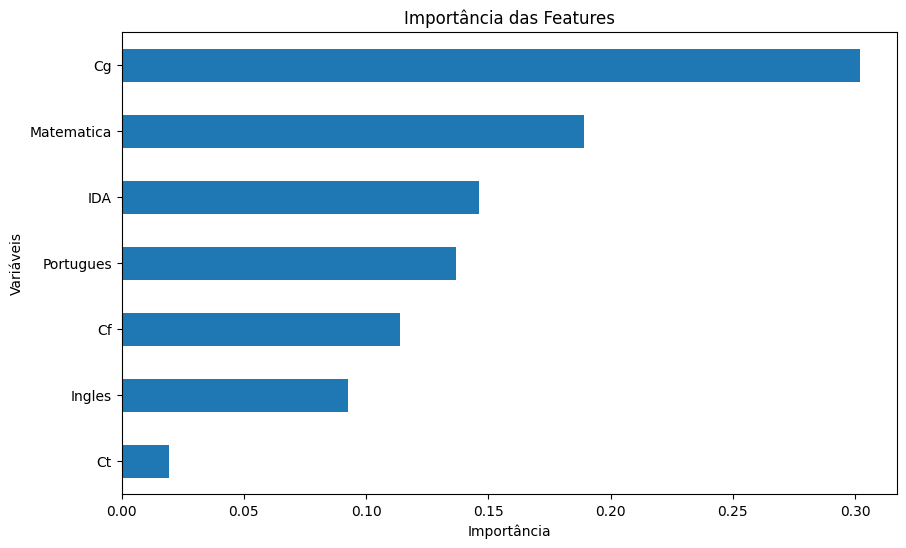

In [16]:
plt.figure(figsize=(10,6))

feat_importance.head(15).plot(
    kind="barh"
)

plt.title("Importância das Features")
plt.xlabel("Importância")
plt.ylabel("Variáveis")

plt.gca().invert_yaxis()

plt.show()

## Análise de Importância das Features

O gráfico acima mostra as **15 features mais importantes** para prever defasagem.

### Variáveis Mais Relevantes:

**IDA** - Indicador de Aprendizagem (Média de Notas)
- Reflete o desempenho acadêmico geral do aluno
- **Importância: CRÍTICA** - Alto poder preditivo

**CG** - Classificação Geral (Ranking)
- Posição relativa do aluno comparado a todos os outros
- **Importância: ALTA** - Fornece contexto global

**CF** - Classificação na Fase
- Ranking do aluno dentro da fase em que está
- **Importância: ALTA** - Identifica alunos fora do ritmo esperado

**CT** - Classificação na Turma
- Posição relativa dentro da turma específica
- **Importância: MODERADA** - Contexto local do desempenho

### Padrão Observado
Métricas de desempenho (IDA) + posicionamento relativo (CG, CF, CT) são as variáveis mais preditivas para detectar defasagem.

## Escolha do modelo final

O modelo escolhido foi o **Gradient Boosting Classifier**.

A escolha foi baseada na comparação das métricas obtidas durante o experimento.

O modelo apresentou:

- maior **ROC-AUC (0.749)** entre os modelos testados
- maior **F1-score (0.746)**, indicando melhor equilíbrio entre precisão e recall
- **alto recall (0.804)**, importante para identificar corretamente alunos em situação de defasagem

Modelos como Random Forest e XGBoost apresentaram desempenho inferior nas métricas principais.

Portanto, o Gradient Boosting foi selecionado como modelo final para o problema de classificação.

In [20]:
best_model_name = results_df.iloc[0]["modelo"]

print("Modelo escolhido:", best_model_name)

final_pipeline = build_pipeline(
    features=features,
    model_name=best_model_name
)

final_pipeline.fit(X_train, y_train)

os.makedirs("../artifacts", exist_ok=True)

model_path = "../artifacts/models/model_experiment.joblib"

joblib.dump(final_pipeline, model_path)

print("Modelo salvo em:", model_path)

Modelo escolhido: gb
Modelo salvo em: ../artifacts/models/model_experiment.joblib


In [22]:
loaded_model = joblib.load("../artifacts/models/model_experiment.joblib")

preds = loaded_model.predict(X_val)

print("Modelo carregado com sucesso")

Modelo carregado com sucesso
